In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pytorch_lightning as pl
from torch.distributions import Bernoulli
import xarray as xr
import xrft
import numpy as np
import matplotlib.pyplot as plt
import src.data
from scipy.stats import multivariate_normal
import pandas as pd
import functools as ft
from collections import namedtuple
from IPython.display import Markdown, display
from omegaconf import OmegaConf
import yaml
import inspect
import hydra
import os
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.colors as colors
from matplotlib.colors import LogNorm 
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from PIL import Image
import kornia.filters as kfilts
from torch.amp import autocast, GradScaler
from scipy.ndimage import gaussian_filter
from scipy.ndimage import binary_dilation
from skimage.morphology import disk, dilation
from sklearn.linear_model import LinearRegression

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#device = "cpu"

# Field Selection

In [2]:
tgt_ds = xr.open_dataset('/Odyssey/public/natl60/ssh/NATL60-CJM165-ssh-2012-2013-1_20.nc')
tgt_ds

<xarray.Dataset> Size: 11GB
Dimensions:       (lat: 780, lon: 1640, time: 365)
Coordinates:
  * lat           (lat) float64 6kB 27.05 27.1 27.15 27.2 ... 65.9 65.95 66.0
  * lon           (lon) float64 13kB -76.95 -76.9 -76.85 -76.8 ... 4.9 4.95 5.0
  * time          (time) datetime64[ns] 3kB 2012-10-01 2012-10-02 ... 2013-09-30
Data variables:
    mdt           (lat, lon) float64 10MB ...
    sla           (time, lat, lon) float64 4GB ...
    ssh           (time, lat, lon) float64 4GB ...
    ssh_norm      (time, lat, lon) float64 4GB ...
    ssh_variance  (lat, lon) float64 10MB ...
Attributes:
    About:    Created by SOSIE interpolation environement => https://github.c...
    Info:     Horizontal grid read in regulargrid_NATL60.nc / Source field re...

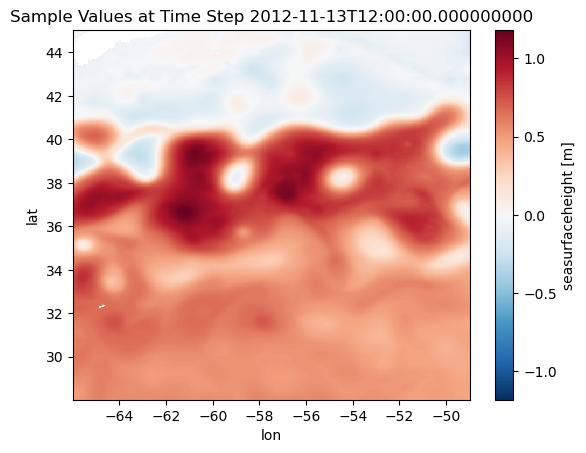

In [3]:
tgt_ds_ecs = xr.open_dataset('/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_cutoff_freq_regrid_0_1000m.nc')
tgt_ds_dim = xr.open_dataset('natl_gf_w_5nadirs.nc')
tgt_ds = xr.open_dataset('/Odyssey/public/natl60/ssh/NATL60-CJM165-ssh-2012-2013-1_20.nc')
time_step_ssh = '2012-11-13T00:00:00.000000000'
time_step     = '2012-11-13T12:00:00.000000000' 
inp_da = tgt_ds.ssh.sel(time=time_step_ssh)
#inp_da = tgt_ds_ecs.ecs.sel(time=time_step)

# lat_shape = len(inp_da_dim.lat)
# lon_shape = len(inp_da_dim.lon)

# crop_lat_start =  20
# crop_lat_end = lat_shape -  20
# crop_lon_start =  20
# crop_lon_end = lon_shape -  20

inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))

border_size = 50

lat_shape = len(inp_da_GS.lat)
lon_shape = len(inp_da_GS.lon)

crop_lat_start =  border_size
crop_lat_end = lat_shape -  border_size
crop_lon_start =  border_size
crop_lon_end = lon_shape -  border_size

inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

inp_da_GS.fillna(0.0)
lambda_value = 15.0
inp_da_GS.plot()
plt.title(f"Sample Values at Time Step {time_step}")
plt.show()

# Warped Field Perturbations

In [4]:
N = lat_shape  # Grid size
L = 5.0  # Spatial correlation length
T_corr = 1.0  # Temporal correlation length
sigma = 20  # Standard deviation of the field
batch_size = 10  # Number of fields to generate
num_fields = batch_size
def generate_correlated_fields(N, L, T_corr, sigma, num_fields=20, device=device,seed=41):
    """
    Generate a series of 2D fields with both spatial and temporal correlations.

    Parameters:
        N (int): Grid size (assumed to be square, NxN).
        L (float): Spatial correlation length.
        T_corr (float): Temporal correlation length.
        sigma (float): Standard deviation of the field.
        num_fields (int): Number of fields to generate (default is 10).
        device (str): Device to run the computations on ('cpu' or 'cuda').

    Returns:
        torch.Tensor: Generated fields of shape (num_fields, N, N).
    """
    torch.manual_seed(seed)
    # Define the time points for the fields
    time_points = torch.linspace(0, num_fields - 1, num_fields, device=device)
    # Compute the temporal covariance matrix
    C_temporal = torch.exp(-abs(time_points[:, None] - time_points[None, :]) / T_corr)
    # Perform Cholesky decomposition to get the temporal correlation factors
    L_chol = torch.linalg.cholesky(C_temporal)
    # Generate independent Gaussian white noise for each time point
    white_noises = torch.randn((num_fields, N, N), device=device)
    # Combine white noise using the Cholesky factors to induce temporal correlation
    temporal_correlated_noises = torch.matmul(L_chol, white_noises.view(num_fields, -1)).view(num_fields, N, N)
    # Generate 2D grid of wavenumbers for spatial correlation
    kx = torch.fft.fftfreq(N, device=device) * N
    ky = torch.fft.fftfreq(N, device=device) * N
    k = torch.sqrt(kx[:, None]**2 + ky[None, :]**2)
    cutoff_mask = (k < 20).float()  # High-frequency cutoff
    # apply - if we apply the same approach to vorticity, and then obtain 
    # stream function, 
    # Spatial covariance (Power spectrum) for Gaussian covariance
    P_k = torch.exp(-0.5 * (k * L)**3)
    P_k[0, 0] = 0.0
    P_k = P_k / torch.sum(P_k)
    # Generate fields using Fourier transform
    fields = []
    for i in range(num_fields):
        noise_ft = torch.fft.fft2(temporal_correlated_noises[i])
        field_ft = noise_ft * sigma**2 * torch.sqrt(P_k) * cutoff_mask
        field = torch.fft.ifft2(field_ft).real
        fields.append(field)
    return torch.stack(fields)

# Generate a Gaussian random field with a high-frequency cutoff
displacement_x = generate_correlated_fields(N, L, T_corr, sigma, num_fields = num_fields, device=device, seed=41)
displacement_y = generate_correlated_fields(N, L, T_corr, sigma, num_fields = num_fields, device=device, seed=414)
# fake_dx=torch.zeros_like(displacement_x)

In [5]:
# We now perturb the fields at the same way,
def warp_field(field, dx, dy):
    """
    Warp a 2D field based on displacement fields dx and dy.
    field (torch.Tensor): Input field of shape (batch_size, height, width)
    dx (torch.Tensor): X-displacement field of shape (batch_size, height, width)
    dy (torch.Tensor): Y-displacement field of shape (batch_size, height, width)
    """
    batch_size, _, height, width = field.shape
    
    # Create base grid
    y, x = torch.meshgrid(torch.arange(height), torch.arange(width), indexing='ij')
    base_grid = torch.stack((x, y), dim=-1).float()
    dx=dx.to(field.dtype)  # Adjust size as needed
    dy=dy.to(field.dtype) 
    # Add batch dimension and move to the same device as input field
    base_grid = base_grid.unsqueeze(0).repeat(batch_size,1,1,1).to(field.device)

    # Apply displacements
    sample_grid = base_grid + torch.stack((dx, dy), dim=-1)
    sample_grid[..., 0] = sample_grid[..., 0] % (width)
    sample_grid[..., 1] = sample_grid[..., 1] % (height)
    

    # Normalize grid to [-1, 1] range
    sample_grid[..., 0] = 2 * sample_grid[..., 0] / (width) - 1
    sample_grid[..., 1] = 2 * sample_grid[..., 1] / (height) - 1

    # Perform sampling
    warped_field = F.grid_sample(field, sample_grid, mode='bilinear', padding_mode='reflection', align_corners=False)
    return warped_field,torch.max(sample_grid), torch.min(sample_grid)

In [6]:
# Prepare data
mean_tgt = inp_da_GS.mean().item()
std_tgt = inp_da_GS.std().item()

tens_inp = torch.from_numpy(inp_da_GS.values).nan_to_num().float().to(device)
tens_inp = (tens_inp - mean_tgt) / std_tgt
tens_inp.unsqueeze_(0)
print(tens_inp.shape)
tens_inp = tens_inp.repeat(batch_size, 1, 1, 1)
# Create a sample field (e.g., a gradient)
field = tens_inp
displacement_x = displacement_x 
displacement_y = displacement_y
mean_x=torch.tensor(0.0)
mean_y=torch.tensor(0.0)
#mean_x=torch.tensor(6.0)
#mean_y=torch.tensor(5.0)

# Perform warping
warped_field,max_grid,min_grid = warp_field(field, displacement_x+mean_x, displacement_y+mean_y)

print(f"Input field shape: {field.shape}")
print(f"Warped field shape: {warped_field.shape}")

torch.Size([1, 340, 340])
Input field shape: torch.Size([10, 1, 340, 340])
Warped field shape: torch.Size([10, 1, 340, 340])


In [7]:
# Function to create a 2D Gaussian kernel
def gaussian_kernel(kernel_size=5, sigma=1.0, dtype=torch.float32, device='cuda'):
    # Create a 2D grid of coordinates (x, y)
    x = torch.arange(kernel_size, dtype=dtype, device=device) - (kernel_size - 1) / 2
    y = torch.arange(kernel_size, dtype=dtype, device=device) - (kernel_size - 1) / 2
    xx, yy = torch.meshgrid(x, y)

    # Compute the Gaussian function on the grid
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))

    # Normalize the kernel to ensure the sum of the weights is 1
    kernel = kernel / kernel.sum()
    return kernel

# Function to apply Gaussian smoothing to a batch of images
def apply_gaussian_smoothing(input_tensor, kernel_size=15, sigma=1.0):
    dtype = input_tensor.dtype
    device = input_tensor.device
    kernel = gaussian_kernel(kernel_size, sigma, dtype=dtype, device=device)
    
    # Reshape the kernel to be [1, 1, kernel_size, kernel_size] (for 2D convolution)
    kernel = kernel.view(1, 1, kernel_size, kernel_size)

    # Expand the kernel to apply it across all channels and the batch
    kernel = kernel.expand(1, 1, kernel_size, kernel_size)

    padding=kernel_size//2
    # Pad the input tensor with circular padding
    padded_input = F.pad(input_tensor, (padding, padding, padding, padding), mode='reflect')

    # Apply the convolution (use groups=batch_size to apply the kernel individually per batch element)
    smoothed_tensor = F.conv2d(padded_input, kernel, groups=1)

    # Remove the extra channel dimension
    return smoothed_tensor 

In [8]:
# Smmothing
smoothed_tensor=apply_gaussian_smoothing(warped_field,kernel_size=10,sigma=1.5)

/Odyssey/private/ochapron/miniconda/miniconda3/envs/fdv/lib/python3.10/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789115564/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


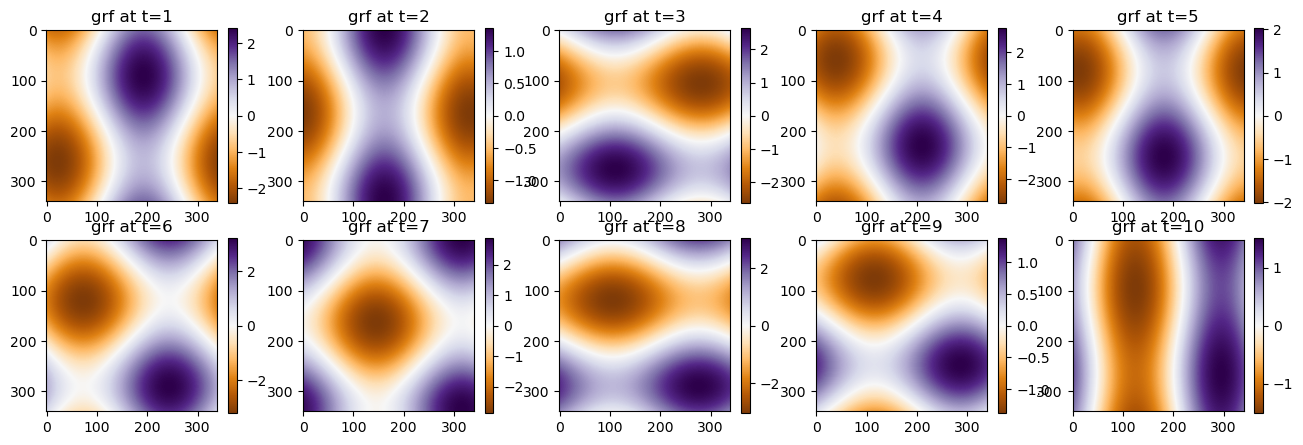

In [9]:
#We now generate a spatially correlated gaussian random field that we can
plt.figure(figsize=(16, 5))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(displacement_x[i].cpu().numpy(), cmap='PuOr')
    plt.colorbar()
    plt.title(f"grf at t={i+1}")

for i in range(5, 10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(displacement_x[i].cpu().numpy(), cmap='PuOr')
    plt.colorbar()
    plt.title(f"grf at t={i+1}")

plt.show()

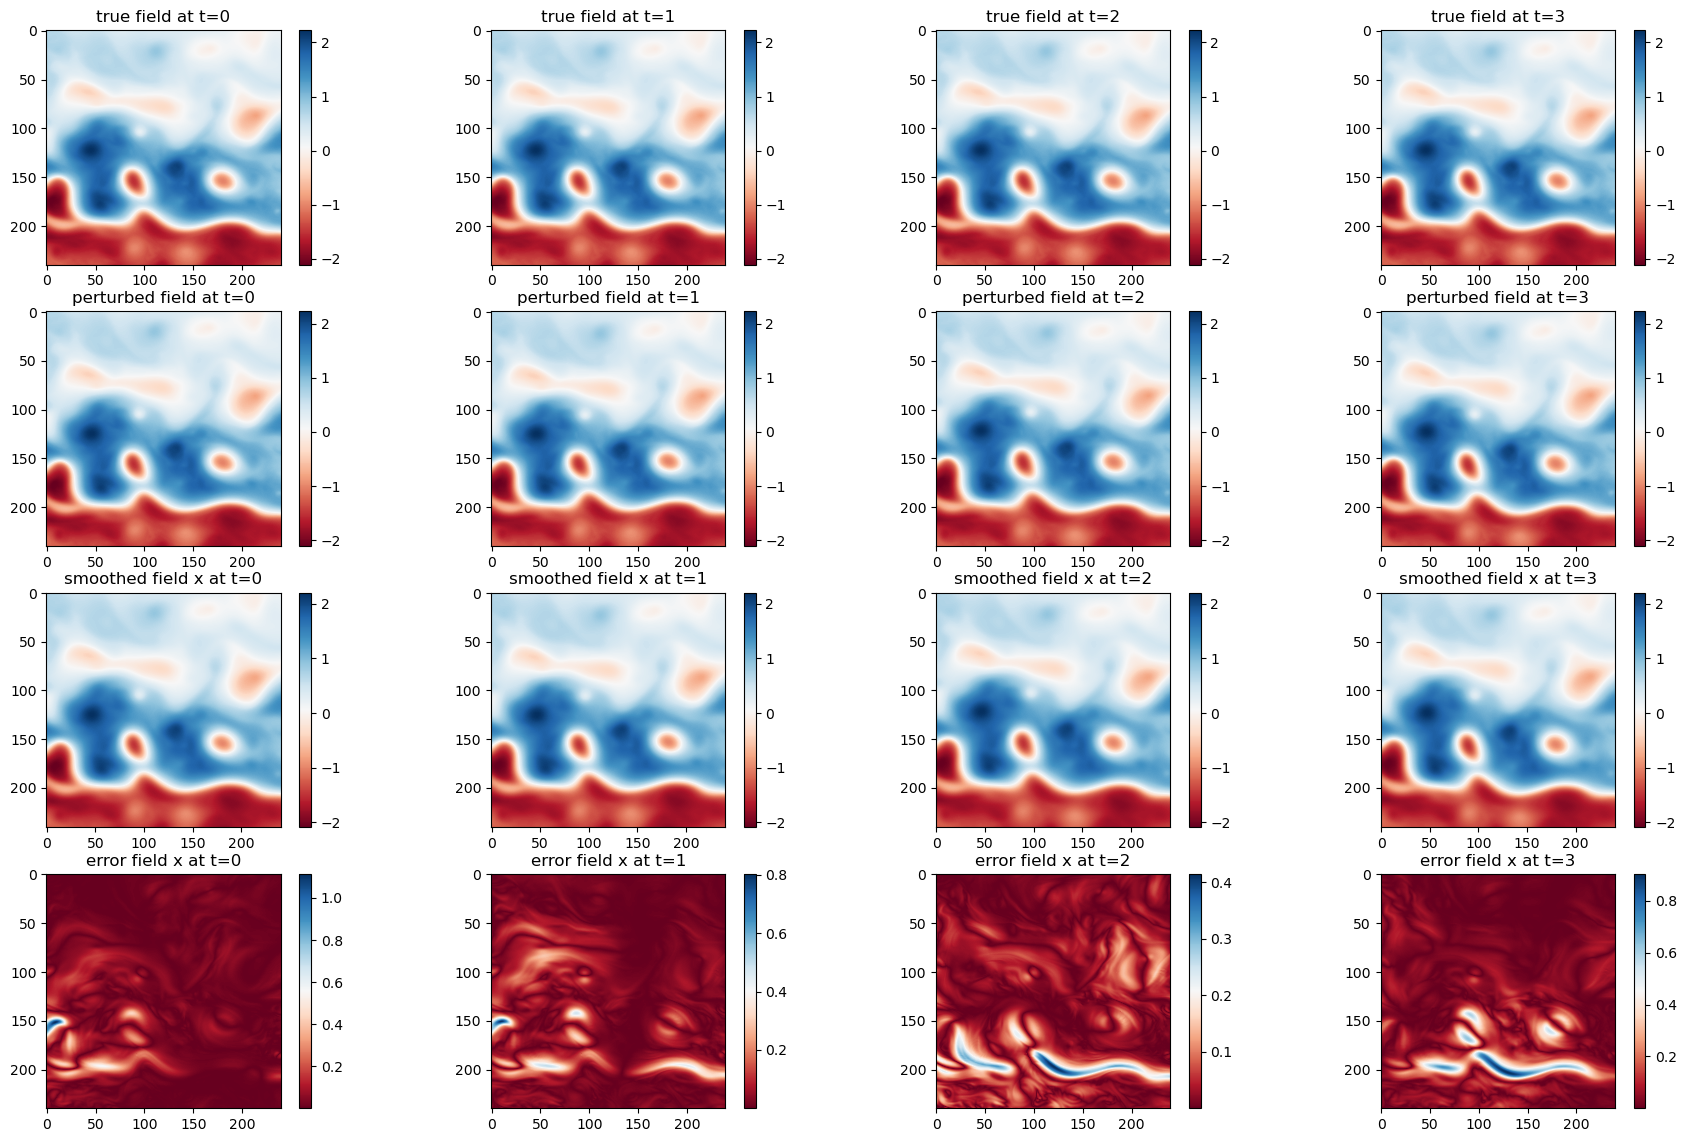

In [10]:
plt.figure(figsize=(22,14))
for i in range(4):
    plt.subplot(4,4,1+i)
    plt.imshow(field[i,0,border_size:-border_size,border_size:-border_size].cpu().numpy(), cmap='RdBu')
    plt.colorbar()
    plt.title(f'true field at t={i}')

    plt.subplot(4,4,5+i)
    plt.imshow(warped_field[i,0,border_size:-border_size,border_size:-border_size].cpu().numpy(), cmap='RdBu')
    plt.colorbar()
    plt.title(f'perturbed field at t={i}')

    plt.subplot(4,4,9+i)
    plt.imshow(smoothed_tensor[i,0,border_size:-border_size,border_size:-border_size].cpu().numpy(), cmap='RdBu')
    plt.colorbar()
    plt.title(f'smoothed field x at t={i}')

    plt.subplot(4,4,13+i)
    plt.imshow(np.abs(warped_field[i,0,border_size:-border_size,border_size:-border_size].cpu().numpy() - field[i,0,border_size:-border_size,border_size:-border_size].cpu().numpy()), cmap='RdBu')
    plt.colorbar()
    plt.title(f'error field x at t={i}')

In [11]:
rmses = []
for i in range(batch_size):
    w_f = warped_field[i,0,border_size:-border_size,border_size:-border_size].cpu().numpy() 
    f =field[i,0,border_size:-border_size,border_size:-border_size].cpu().numpy()
    rmse = np.sqrt(np.mean((f - w_f) ** 2))
    rmses.append(rmse)
    print(f"RMSE for warped field {i}: {rmse}")
    
mean_rmse = np.mean(rmses)
print(f"Mean RMSE: {mean_rmse}")

RMSE for warped field 0: 0.0911424532532692
RMSE for warped field 1: 0.0883897989988327
RMSE for warped field 2: 0.06931943446397781
RMSE for warped field 3: 0.1355588138103485
RMSE for warped field 4: 0.04796118661761284
RMSE for warped field 5: 0.14728426933288574
RMSE for warped field 6: 0.08774785697460175
RMSE for warped field 7: 0.07973188161849976
RMSE for warped field 8: 0.13098950684070587
RMSE for warped field 9: 0.10309699177742004
Mean RMSE: 0.09812221676111221


In [12]:
def rmse_based_scores_from_ds(ds, ref_variable='out', study_variable='tgt'):
    #mask = ~np.isnan(ds['input'])
    try:
        return rmse_based_scores(ds[ref_variable], ds[study_variable])[2:]
    except:
        return [np.nan, np.nan]

def psd_based_scores_from_ds(ds, ref_variable='out', study_variable='tgt'):
    try:
        return psd_based_scores(ds[ref_variable], ds[study_variable])[1:]
    except:
        return [np.nan, np.nan]

def rmse_based_scores_lead(da_rec, da_ref):
    rmse_t = (
        1.0
        - (((da_rec - da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
        / (((da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
    )
    rmse_xy = (((da_rec - da_ref) ** 2).mean(dim=("time"))) ** 0.5
    rmse_t = rmse_t.rename("rmse_t")
    rmse_xy = rmse_xy.rename("rmse_xy")
    reconstruction_error_stability_metric = rmse_t.std().values
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return (
        np.round(leaderboard_rmse.values, 5).item(),
        np.round(reconstruction_error_stability_metric, 5).item(),
    )

def rmse_based_scores_day(da_rec, da_ref):
    # Calculate leaderboard RMSE
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return np.round(leaderboard_rmse.values, 5).item()

def rmse_based_scores(da_rec, da_ref):
    rmse_t = (
        1.0
        - (((da_rec - da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
        / (((da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
    )
    rmse_xy = (((da_rec - da_ref) ** 2).mean(dim=("time"))) ** 0.5
    rmse_t = rmse_t.rename("rmse_t")
    rmse_xy = rmse_xy.rename("rmse_xy")
    reconstruction_error_stability_metric = rmse_t.std().values
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return (
        rmse_t,
        rmse_xy,
        np.round(leaderboard_rmse.values, 5).item(),
        np.round(reconstruction_error_stability_metric, 5).item(),
    )

def psd_based_scores(da_rec, da_ref):
    err = da_rec - da_ref
    err["time"] = (err.time - err.time[0]) / np.timedelta64(1, "D")
    signal = da_ref
    signal["time"] = (signal.time - signal.time[0]) / np.timedelta64(1, "D")
    psd_err = xrft.power_spectrum(
        err, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()
    psd_signal = xrft.power_spectrum(
        signal, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()

    mean_psd_signal = psd_signal.mean(dim="lat").where(
        (psd_signal.freq_lon > 0.0) & (psd_signal.freq_time > 0), drop=True
    )
    
    mean_psd_err = psd_err.mean(dim="lat").where(
        (psd_err.freq_lon > 0.0) & (psd_err.freq_time > 0), drop=True
    )
    psd_based_score = 1.0 - mean_psd_err / mean_psd_signal
    level = [0.5]
    cs = plt.contour(
        1.0 / psd_based_score.freq_lon.values,
        1.0 / psd_based_score.freq_time.values,
        psd_based_score,
        level,
    )
    x05, y05 = cs.collections[0].get_paths()[0].vertices.T
    plt.close()

    shortest_spatial_wavelength_resolved = np.min(x05)
    shortest_temporal_wavelength_resolved = np.min(y05)
    psd_da = 1.0 - mean_psd_err / mean_psd_signal
    psd_da.name = "psd_score"
    return (
        psd_da.to_dataset(),
        np.round(shortest_spatial_wavelength_resolved, 3).item(),
        np.round(shortest_temporal_wavelength_resolved, 3).item(),
    )

In [13]:
warped_field_np = warped_field[:, 0, border_size:-border_size, border_size:-border_size].cpu().numpy()

warped_field_da = xr.DataArray(
    warped_field_np,
    dims=["time", "lat", "lon"],
    coords={
        "time": pd.date_range(start="2000-01-01", periods=warped_field_np.shape[0], freq="D"),
        "lat": inp_da_GS_crop.lat,
        "lon": inp_da_GS_crop.lon
    },
    name="warped_field"
)

smoothed_field_np = smoothed_tensor[:, 0, border_size:-(border_size+1), border_size:-(border_size+1)].cpu().numpy()
smoothed_field_da = xr.DataArray(
    smoothed_field_np,
    dims=["time", "lat", "lon"],
    coords={
        "time": pd.date_range(start="2000-01-01", periods=smoothed_field_np.shape[0], freq="D"),
        "lat": inp_da_GS_crop.lat,
        "lon": inp_da_GS_crop.lon
    },
    name="warped_smooth_field"
)

# Convert the tensor f to a numpy array
f = field[:, 0, border_size:-border_size, border_size:-border_size].cpu().numpy()

# Create a new xarray DataArray with the same dimensions as inp_da_GS_crop
f_da = xr.DataArray(
    f,
    dims=["time", "lat", "lon"],
    coords={
        "time": pd.date_range(start="2000-01-01", periods=f.shape[0], freq="D"),
        "lat": inp_da_GS_crop.lat,
        "lon": inp_da_GS_crop.lon
    },
    name="field"
)

new_dataset = xr.Dataset({
    'tgt': f_da,
    'out': warped_field_da,
    'out_smooth': smoothed_field_da
})
# Display the new dataset
new_dataset

<xarray.Dataset> Size: 7MB
Dimensions:     (time: 10, lat: 240, lon: 240)
Coordinates:
  * time        (time) datetime64[ns] 80B 2000-01-01 2000-01-02 ... 2000-01-10
  * lat         (lat) float64 2kB 30.55 30.6 30.65 30.7 ... 42.4 42.45 42.5
  * lon         (lon) float64 2kB -63.45 -63.4 -63.35 ... -51.6 -51.55 -51.5
Data variables:
    tgt         (time, lat, lon) float32 2MB 0.686 0.682 ... -1.396 -1.392
    out         (time, lat, lon) float32 2MB 0.6853 0.6829 ... -1.396 -1.392
    out_smooth  (time, lat, lon) float32 2MB 0.6789 0.6771 ... -1.412 -1.408

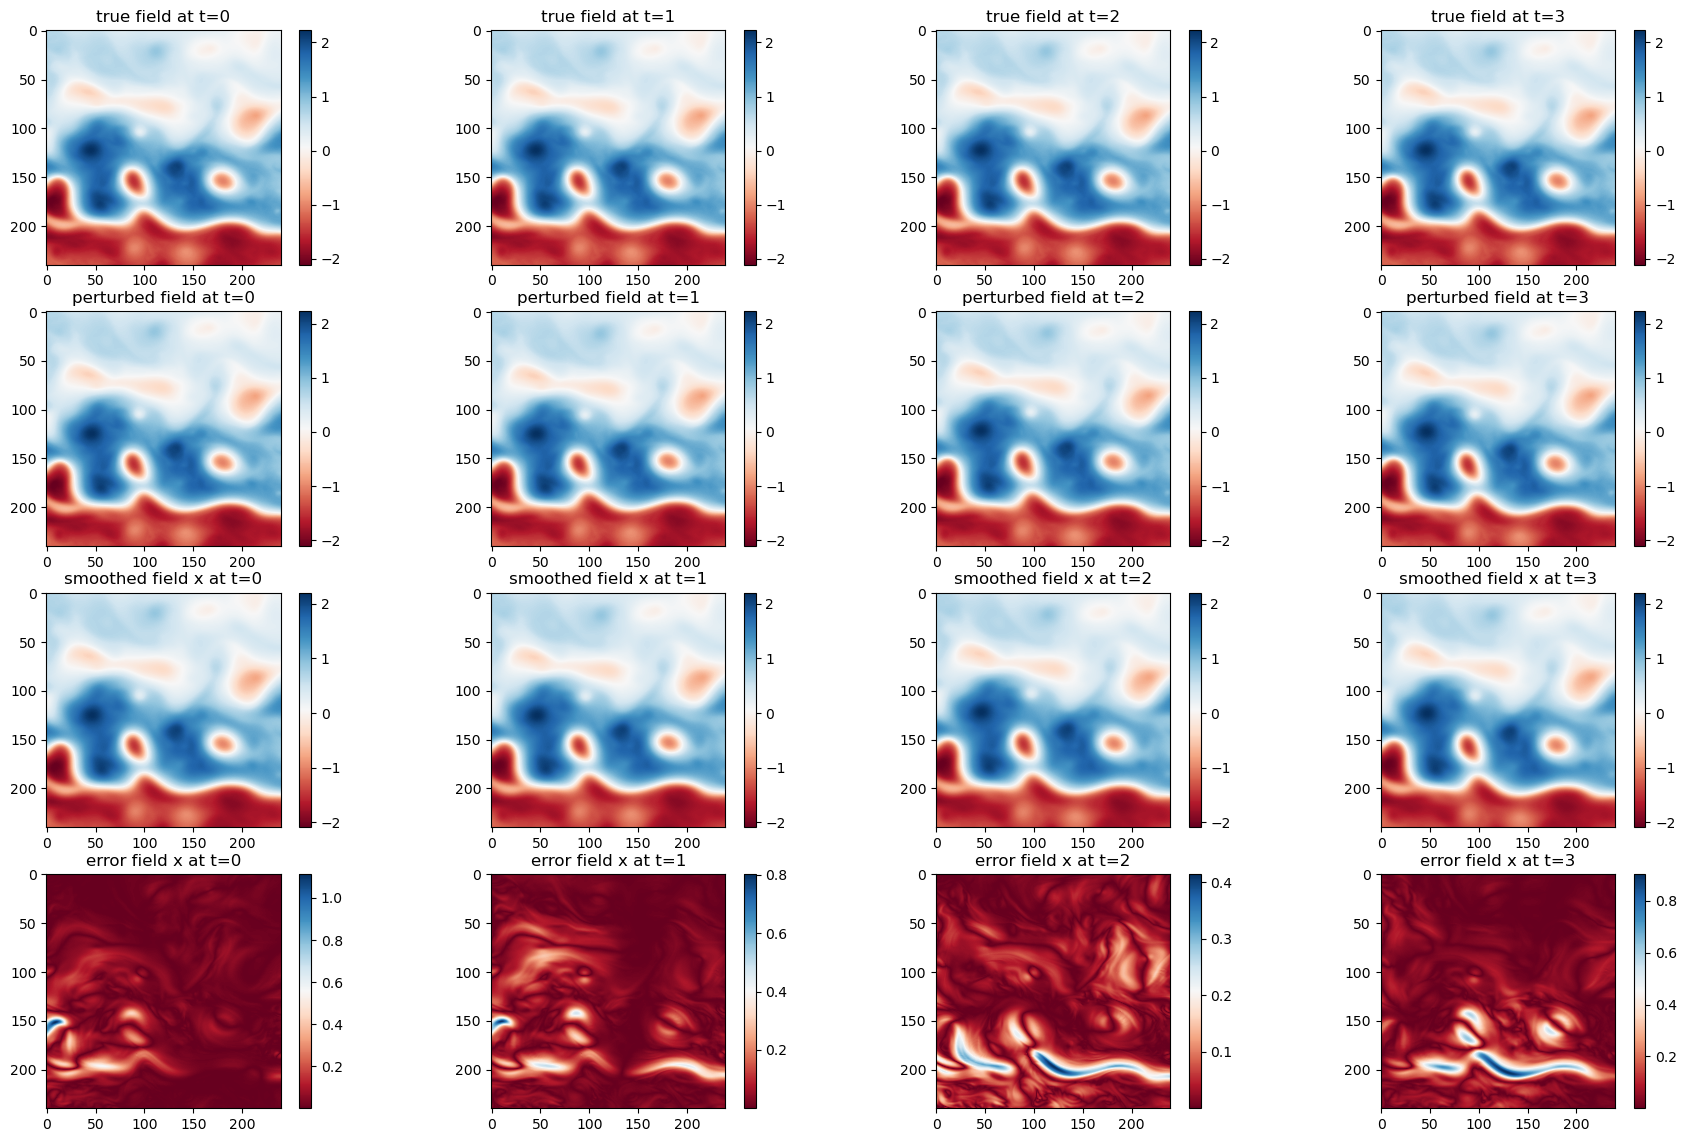

In [14]:
plt.figure(figsize=(22,14))
for i in range(4):
    tgt = new_dataset.tgt[i]
    out = new_dataset.out[i]
    out_smooth = new_dataset.out_smooth[i]
    plt.subplot(4,4,1+i)
    plt.imshow(tgt, cmap='RdBu')
    plt.colorbar()
    plt.title(f'true field at t={i}')

    plt.subplot(4,4,5+i)
    plt.imshow(out, cmap='RdBu')
    plt.colorbar()
    plt.title(f'perturbed field at t={i}')

    plt.subplot(4,4,9+i)
    plt.imshow(out_smooth, cmap='RdBu')
    plt.colorbar()
    plt.title(f'smoothed field x at t={i}')

    plt.subplot(4,4,13+i)
    plt.imshow(np.abs(out - tgt), cmap='RdBu')
    plt.colorbar()
    plt.title(f'error field x at t={i}')

In [15]:
print('PSD scores')
lx, ly = psd_based_scores_from_ds(new_dataset, ref_variable='out', study_variable='tgt')
print(lx, ly)
print('RMSE scores')
mu, sig = rmse_based_scores_from_ds(new_dataset, ref_variable='out', study_variable='tgt')
print(mu, sig)

PSD scores
0.952 10.0
RMSE scores
0.90081 0.02879


/tmp/ipykernel_2510323/1850958367.py:86: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  x05, y05 = cs.collections[0].get_paths()[0].vertices.T


In [16]:
def psd_based_scores_from_ds(ds, ref_variable='out', study_variable='tgt'):
    try:
        return psd_based_scores(ds[ref_variable], ds[study_variable])[1:]
    except:
        return [np.nan, np.nan]


def psd_based_scores(da_rec, da_ref):
    err = da_rec - da_ref
    err["time"] = (err.time - err.time[0]) / np.timedelta64(1, "D")
    signal = da_ref
    signal["time"] = (signal.time - signal.time[0]) / np.timedelta64(1, "D")
    psd_err = xrft.power_spectrum(
        err, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()
    psd_signal = xrft.power_spectrum(
        signal, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()

    mean_psd_signal = psd_signal.mean(dim="lat").where(
        (psd_signal.freq_lon > 0.0) & (psd_signal.freq_time > 0), drop=True
    )
    
    mean_psd_err = psd_err.mean(dim="lat").where(
        (psd_err.freq_lon > 0.0) & (psd_err.freq_time > 0), drop=True
    )
    psd_based_score = 1.0 - mean_psd_err / mean_psd_signal
    level = [0.5]
    cs = plt.contour(
        1.0 / psd_based_score.freq_lon.values,
        1.0 / psd_based_score.freq_time.values,
        psd_based_score,
        level,
    )
    x05, y05 = cs.collections[0].get_paths()[0].vertices.T
    plt.close()

    shortest_spatial_wavelength_resolved = np.min(x05)
    shortest_temporal_wavelength_resolved = np.min(y05)
    psd_da = 1.0 - mean_psd_err / mean_psd_signal
    psd_da.name = "psd_score"
    return (
        psd_da.to_dataset(),
        np.round(shortest_spatial_wavelength_resolved, 3).item(),
        np.round(shortest_temporal_wavelength_resolved, 3).item(),
    )

In [17]:
def psd_based_scores_spatial(da_rec, da_ref):
    # Calculate error field
    err = da_rec - da_ref
    
    # Remove time coordinate if present (assuming single time step)
    if 'time' in err.dims:
        err = err.isel(time=0).drop('time')
    if 'time' in da_ref.dims:
        signal = da_ref.isel(time=0).drop('time')
        out = da_rec.isel(time=0).drop('time')
    else:
        signal = da_ref
        out = da_rec
    # Compute power spectral densities
    psd_err = xrft.power_spectrum(
        err, dim=["lon"], detrend="constant", window="hann"
    ).compute()
    psd_signal = xrft.power_spectrum(
        signal, dim=["lon"], detrend="constant", window="hann"
    ).compute()
    psd_out = xrft.power_spectrum(
        out, dim=["lon"], detrend="constant", window="hann"
    ).compute()
    # Average over latitude and filter positive frequencies
    mean_psd_signal = psd_signal.mean(dim="lat").where(psd_signal.freq_lon > 0.0, drop=True)
    mean_psd_out = psd_out.mean(dim="lat").where(psd_out.freq_lon > 0.0, drop=True)
    mean_psd_err = psd_err.mean(dim="lat").where(psd_err.freq_lon > 0.0, drop=True)

    # Calculate PSD-based score
    psd_based_score = 1.0 - (mean_psd_err / mean_psd_signal)

    # Find shortest wavelength where score >= 0.5
    mask = psd_based_score >= 0.5
    if mask.any():
        valid_freqs = psd_based_score.freq_lon.where(mask, drop=True)
        if valid_freqs.size > 0:
            max_freq = valid_freqs.max().values
            shortest_wavelength = 1.0 / max_freq
        else:
            shortest_wavelength = np.nan
    else:
        shortest_wavelength = np.nan

    # Round and format output
    shortest_wavelength_rounded = np.round(shortest_wavelength, 3).item() if not np.isnan(shortest_wavelength) else np.nan

    # Prepare output dataset
    psd_ds = xr.Dataset({
        'psd_score': psd_based_score,
        'mean_psd_signal': mean_psd_signal,
        'mean_psd_err': mean_psd_err,
        'mean_psd_out': mean_psd_out
    })

    return (psd_ds, shortest_wavelength_rounded)

In [18]:
lxdays = []
for i in range(batch_size):
    psd, x = psd_based_scores_spatial(new_dataset.out[i], new_dataset.tgt[i])
    lxdays.append(x)
    print(x)

mean_xdays = np.nanmean(lxdays)
print('mean_xdays', mean_xdays)


0.462
0.324
0.571
0.923
0.48
1.2
1.091
0.75
0.632
0.632
mean_xdays 0.7064999999999999


In [19]:
def plot_psd_analysis(psd_ds, shortest_wavelength):
    """Plot PSD components and spatial resolution threshold"""
    fig, axs = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
    
    # Convert frequency to wavelength
    wavelength = 1.0 / psd_ds.freq_lon
    
    # Plot signal PSD
    axs[0].loglog(wavelength, psd_ds.mean_psd_signal,  # Changed here
                 label='Signal PSD', color='blue')
    axs[0].loglog(wavelength, psd_ds.mean_psd_err,  # Changed here
                 label='Error PSD', color='red')
    axs[0].loglog(wavelength, psd_ds.mean_psd_out,  # Changed here
                 label='Out PSD', color='green') 
    axs[0].set_ylabel('Power Spectral Density')
    axs[0].set_title('Signal and Error Power Spectrum')
    axs[0].set_xlabel('Wavelength (degrees)')
    axs[0].grid(True, which='both')    
    axs[0].legend()

    # Plot PSD-based score
    axs[1].semilogx(wavelength, psd_ds.psd_score,  # Changed here
                   label='PSD Score', color='darkgreen')
    axs[1].axhline(0.5, color='red', linestyle='--', 
                  label='Threshold (0.5)')
    axs[1].axvline(shortest_wavelength, color='orange', linestyle=':',
                  label=f'Resolution: {shortest_wavelength:.2f}°')
    axs[1].set_ylabel('Score (1 - Error/Signal)')
    axs[1].set_xlabel('Wavelength (degrees)')
    axs[1].set_title('Spectral Resolution Score')
    axs[1].grid(True, which='both')
    axs[1].legend()

    plt.tight_layout()
    return fig, axs

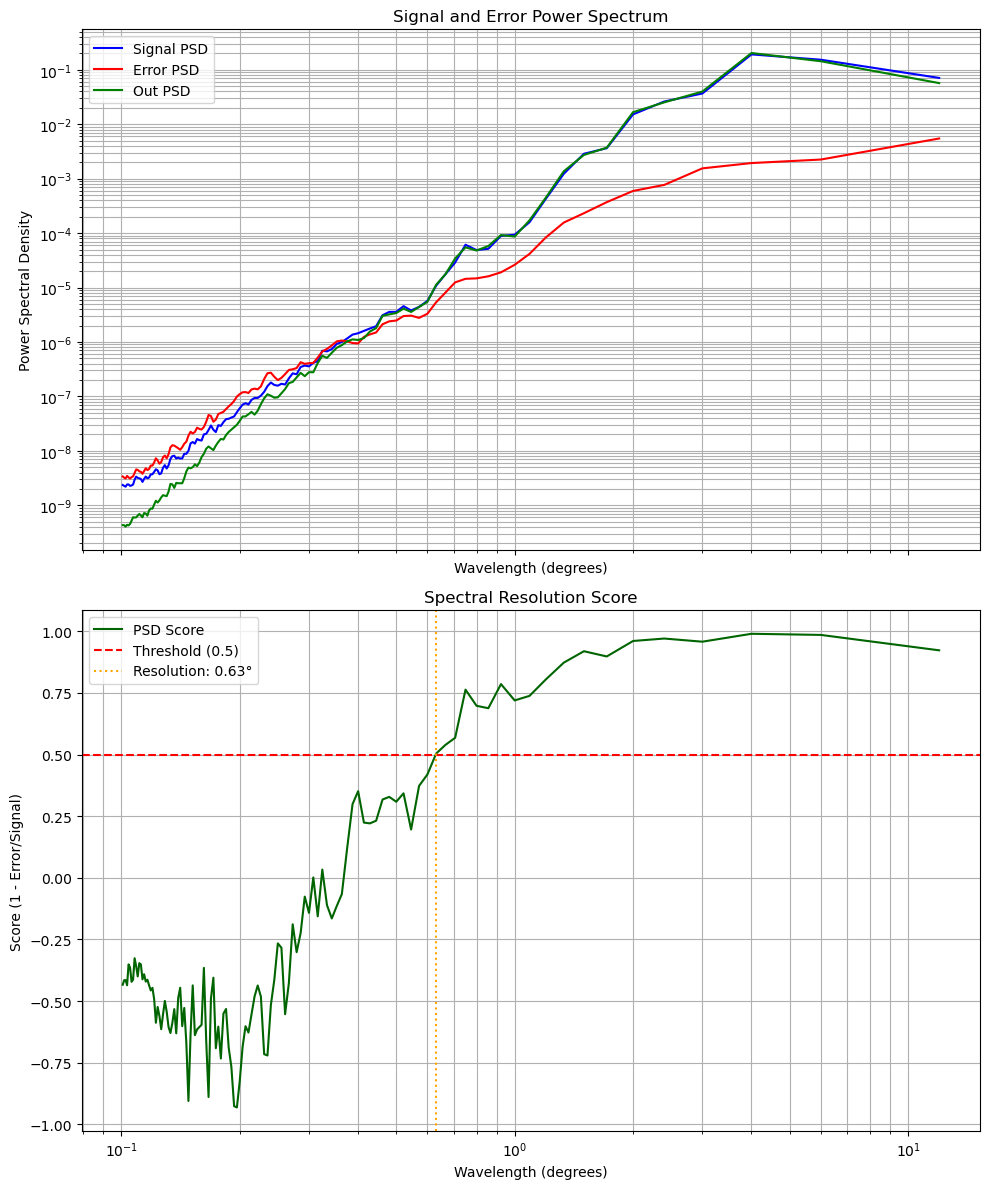

In [20]:
# After computing the scores
psd_results, resolution = psd_based_scores_spatial(new_dataset.out[9], new_dataset.tgt[9])

# Generate plots
fig, axs = plot_psd_analysis(psd_results, resolution)
plt.show()